# Check the mask integrity
Algunas máscaras pueden incluir pedazos de cráneo y de líquido cefaloraquídeo. Se validará en los conjuntos de datos AISD y ISLES los casos donde las máscaras incluyan tejido distinto al encéfalo.

In [1]:
import os
import SimpleITK as sitk
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [2]:
base_path = "D:/jm.rivera/nnUnet_data/nnUNet_raw/Dataset002_AISDnISLES"
imagesTr = os.path.join(base_path, "imagesTr")
labelsTr = os.path.join(base_path, "labelsTr")
dataset_id="AISDnISLES"

In [3]:
def apply_window(image, wl, ww):
    lower = wl - ww / 2
    upper = wl + ww / 2
    windowed = np.clip(image, lower, upper)
    return windowed

# Find images that might have included skull or spinal fluid in the mask

In [4]:
images_list = os.listdir(imagesTr)
labels_list = os.listdir(labelsTr)

In [5]:
min=[]
max=[]
mean=[]
for i in range(len(images_list)):
    ct_image = sitk.ReadImage(os.path.join(imagesTr, images_list[i]))

    ct_np = sitk.GetArrayFromImage(ct_image)      # (z,y,x)
    
    min.append(ct_np.min())
    max.append(ct_np.max())
    mean.append(ct_np.mean())


In [6]:
df = pd.DataFrame.from_dict(
    {
        "min":min,
        "max":max,
        "meam":mean
    }
)

In [7]:
df.describe()

,min,max,meam
count,546.000000,546.000000,546.000000
mean,-1435.241699,2265.404785,-511.671761
std,1661.471069,447.741974,88.034979
min,-8192.000000,1419.000000,-868.558838
25%,-1024.000000,1926.250000,-566.666037
50%,-1024.000000,2087.000000,-505.209847
75%,-1024.000000,2697.000000,-449.884034
max,-1015.000000,3076.000000,-285.033072


In [8]:
df[df['min'] < -2000]

,min,max,meam
490,-8192.0,2088.0,-566.329651
491,-8192.0,2069.0,-587.072388
493,-8192.0,2099.0,-805.559692
496,-8192.0,2149.0,-553.620728
497,-8192.0,2151.0,-414.733185
499,-8192.0,2083.0,-476.456055
500,-8192.0,2091.0,-537.082397
502,-8192.0,2126.0,-501.408051
504,-8192.0,2105.0,-617.609436
505,-8192.0,2102.0,-727.230957


In [45]:
for i in range(len(images_list)):
    ct_image = sitk.ReadImage(os.path.join(imagesTr, images_list[i]))
    mask_image = sitk.ReadImage(os.path.join(labelsTr, labels_list[i]))

    ct_np = sitk.GetArrayFromImage(ct_image)      # (z,y,x)
    mask_np = sitk.GetArrayFromImage(mask_image)  # (z,y,x)

    lesion_np = ct_np*mask_np
    if np.sum(lesion_np < -2000) > 0:
        print(i)

In [9]:
all_mask_values = []
aisd_values = []
isles_values = []
for i in range(len(images_list)):
    ct_image = sitk.ReadImage(os.path.join(imagesTr, images_list[i]))
    mask_image = sitk.ReadImage(os.path.join(labelsTr, labels_list[i]))

    ct_np = sitk.GetArrayFromImage(ct_image)      # (z,y,x)
    mask_np = sitk.GetArrayFromImage(mask_image)  # (z,y,x)

    all_mask_values.append(ct_np[mask_np > 0])
    if(i < 397):
        aisd_values.append(ct_np[mask_np > 0])
    else:
        isles_values.append(ct_np[mask_np > 0])

In [10]:
all_mask_values = np.concatenate(all_mask_values)
aisd_values = np.concatenate(aisd_values)
isles_values = np.concatenate(isles_values)

In [18]:
print("Count:", all_mask_values.size)
print("Mean:", np.mean(all_mask_values))
print("Std:", np.std(all_mask_values))
print("Min:", np.min(all_mask_values))
print("0.5%:", np.percentile(all_mask_values, 0.5))
print("25%:", np.percentile(all_mask_values, 25))
print("50% (median):", np.percentile(all_mask_values, 50))
print("75%:", np.percentile(all_mask_values, 75))
print("95%:", np.percentile(all_mask_values, 95))
print("99%:", np.percentile(all_mask_values, 99))
print("99,5%:", np.percentile(all_mask_values, 99.5))
print("Max:", np.max(all_mask_values))

print("Voxels > 200 HU:", np.sum(all_mask_values > 200))
print("Voxels > 300 HU:", np.sum(all_mask_values > 300))
print("Voxels < 0 HU:", np.sum(all_mask_values < 0))
print("Voxels < -100 HU:", np.sum(all_mask_values < -100))

Count: 28349834
Mean: 32.54349
Std: 52.53325
Min: -1000.0
0.5%: 6.0
25%: 23.0
50% (median): 28.0
75%: 33.0
95%: 42.0
99%: 148.0
99,5%: 354.0
Max: 1670.0
Voxels > 200 HU: 230422
Voxels > 300 HU: 165223
Voxels < 0 HU: 10500
Voxels < -100 HU: 56


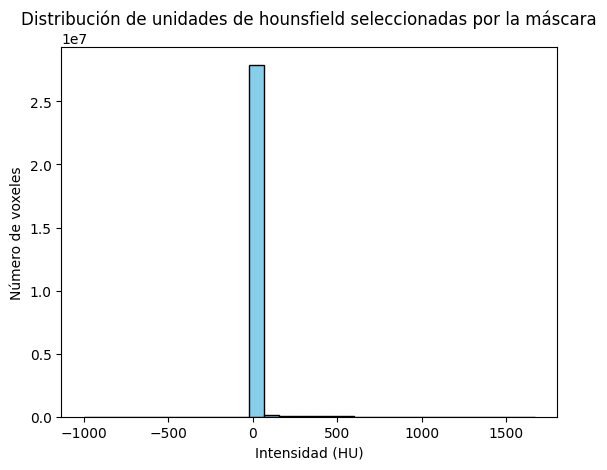

In [12]:
plt.hist(all_mask_values, bins=30, color='skyblue', edgecolor='black') #

# 3. Add labels and title
plt.title("Distribución de unidades de hounsfield seleccionadas por la máscara")
plt.xlabel("Intensidad (HU)")
plt.ylabel("Número de voxeles")

# 4. Display the plot
plt.show()

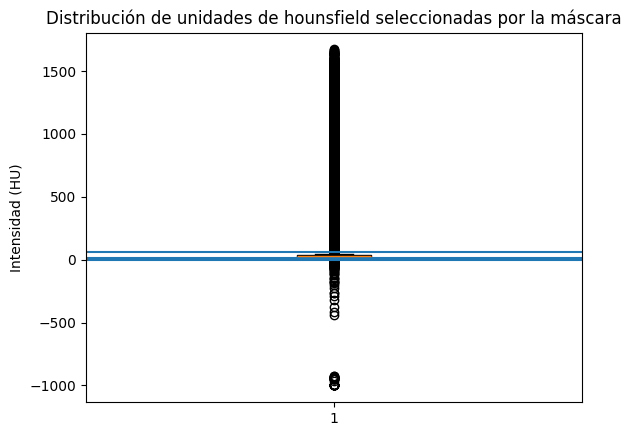

In [13]:
plt.boxplot(all_mask_values) #

# 3. Add labels and title
plt.title("Distribución de unidades de hounsfield seleccionadas por la máscara")
plt.ylabel("Intensidad (HU)")

plt.axhline(0)
plt.axhline(15)
plt.axhline(60)

# 4. Display the plot
plt.show()

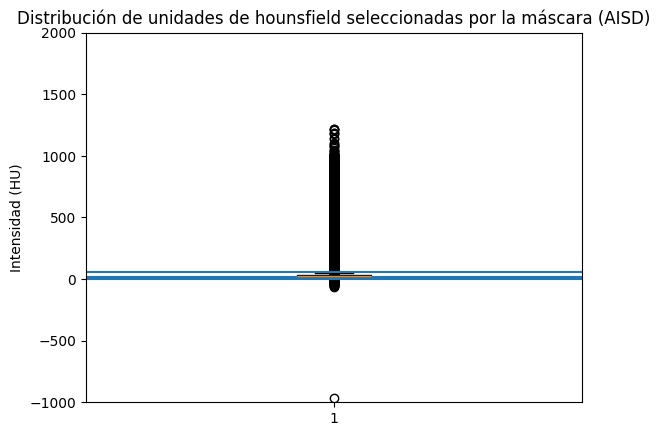

In [16]:
plt.boxplot(aisd_values) #

# 3. Add labels and title
plt.title("Distribución de unidades de hounsfield seleccionadas por la máscara (AISD)")
plt.ylabel("Intensidad (HU)")

plt.axhline(0)
plt.axhline(15)
plt.axhline(60)

plt.ylim(-1000,2000)

# 4. Display the plot
plt.show()

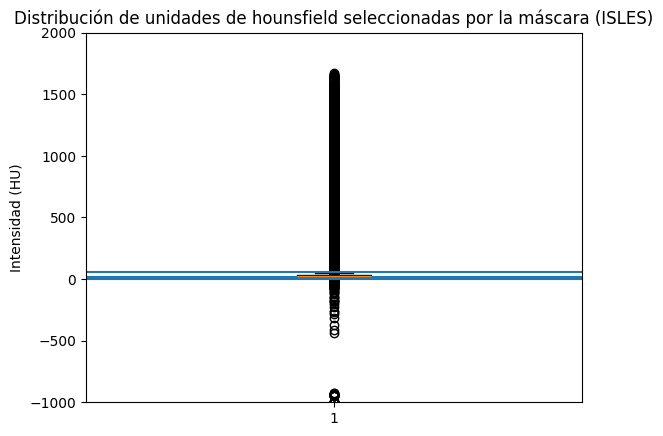

In [17]:
plt.boxplot(isles_values) #

# 3. Add labels and title
plt.title("Distribución de unidades de hounsfield seleccionadas por la máscara (ISLES)")
plt.ylabel("Intensidad (HU)")

plt.axhline(0)
plt.axhline(15)
plt.axhline(60)

plt.ylim(-1000,2000)

# 4. Display the plot
plt.show()

In [19]:
wl = 40
ww = 40

Showing slice 26 (largest lesion area)


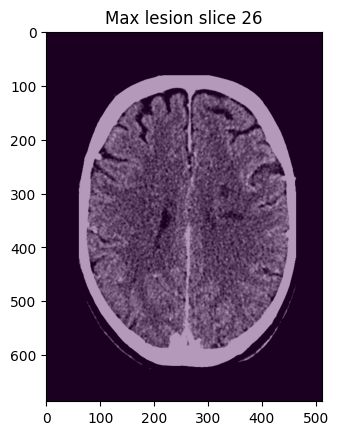

In [47]:
ct_image = sitk.ReadImage(os.path.join(imagesTr, images_list[490]))
mask_image = sitk.ReadImage(os.path.join(labelsTr, labels_list[490]))

ct_np = sitk.GetArrayFromImage(ct_image)      # (z,y,x)
mask_np = sitk.GetArrayFromImage(mask_image)  # (z,y,x)

lesion_np = ct_np*mask_np

# Find slices containing lesion
lesion_area_per_slice = mask_np.sum(axis=(1,2))
z = np.argmax(lesion_area_per_slice)
windowed_slice = apply_window(ct_np[z], wl, ww)

out_of_range_pixels = np.array((lesion_np > 50) & (lesion_np < 15), dtype=np.uint16)

if lesion_area_per_slice[z] == 0:
    print("⚠️ Empty mask")
else:
    print(f"Showing slice {z} (largest lesion area)")
    
    plt.imshow(windowed_slice, cmap="gray")
    plt.imshow(out_of_range_pixels[z], alpha=0.4)
    plt.title(f"Max lesion slice {z}")
    plt.show()

Showing slice 38 (largest lesion area)


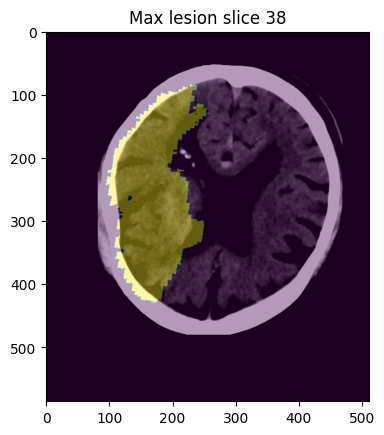

In [11]:
index = '411'

wl = 40
ww = 40

ct_image = sitk.ReadImage(os.path.join(imagesTr, f'{dataset_id}_{index}_0000.nii.gz'))
mask_image = sitk.ReadImage(os.path.join(labelsTr, f'{dataset_id}_{index}.nii.gz'))

ct_np = sitk.GetArrayFromImage(ct_image)      # (z,y,x)
mask_np = sitk.GetArrayFromImage(mask_image)  # (z,y,x)

# Find slices containing lesion
lesion_area_per_slice = mask_np.sum(axis=(1,2))
z = np.argmax(lesion_area_per_slice)
windowed_slice = apply_window(ct_np[z], wl, ww)

if lesion_area_per_slice[z] == 0:
    print("⚠️ Empty mask")
else:
    print(f"Showing slice {z} (largest lesion area)")
    
    plt.imshow(windowed_slice, cmap="gray")
    plt.imshow(mask_np[z], alpha=0.4)
    plt.title(f"Max lesion slice {z}")
    plt.show()